# Train and Tune Linear Regression Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.recursive import recursive_forecast
from src.models.factory import Experiment
from src.models.linreg import LinearElasticNet
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, \
    plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-09-04 21:39:32,503 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "linreg"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: LinearElasticNet(horizon=horizon, random_state=seed, multioutput=True),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=100, n_splits=5)

2025-09-04 21:39:32,570 - INFO - ModelTrainer - Initialized ModelTrainer for model: linreg
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.993e-01, tolerance: 2.270e-02
  model = cd_fast.enet_coordinate_descent(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.520e-01, tolerance: 2.270e-02
  model = cd_fast.enet_coordinate_descent(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

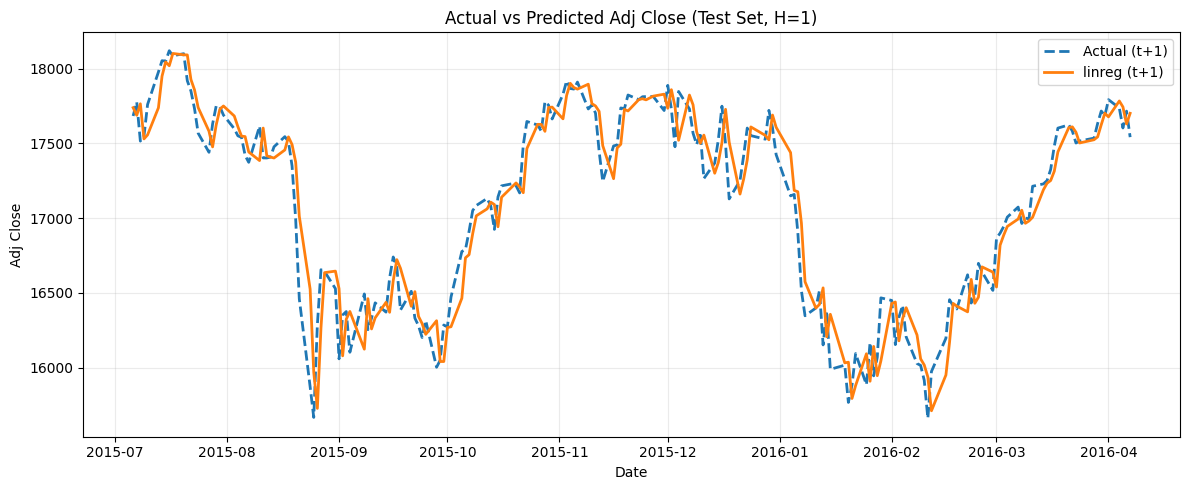

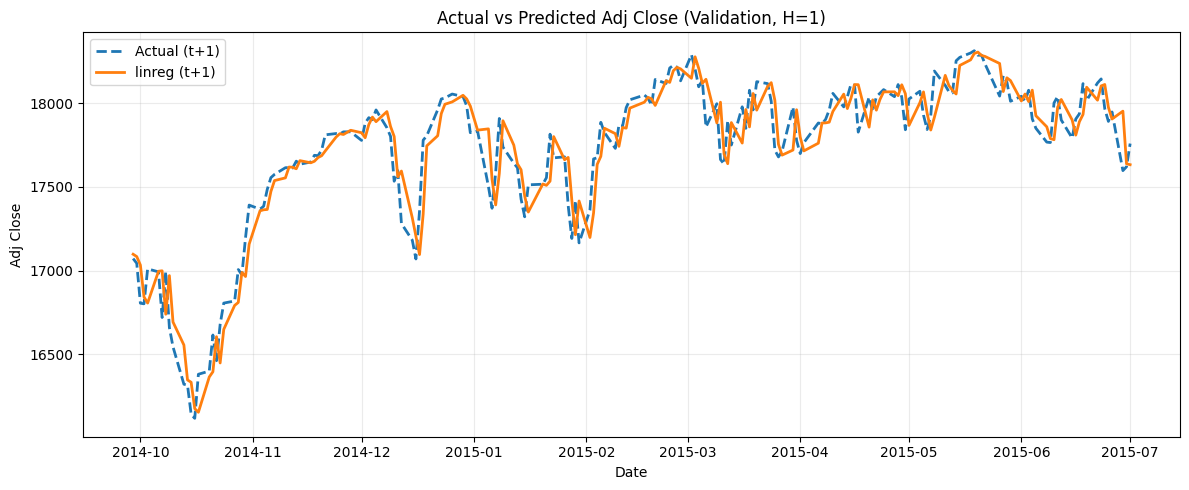

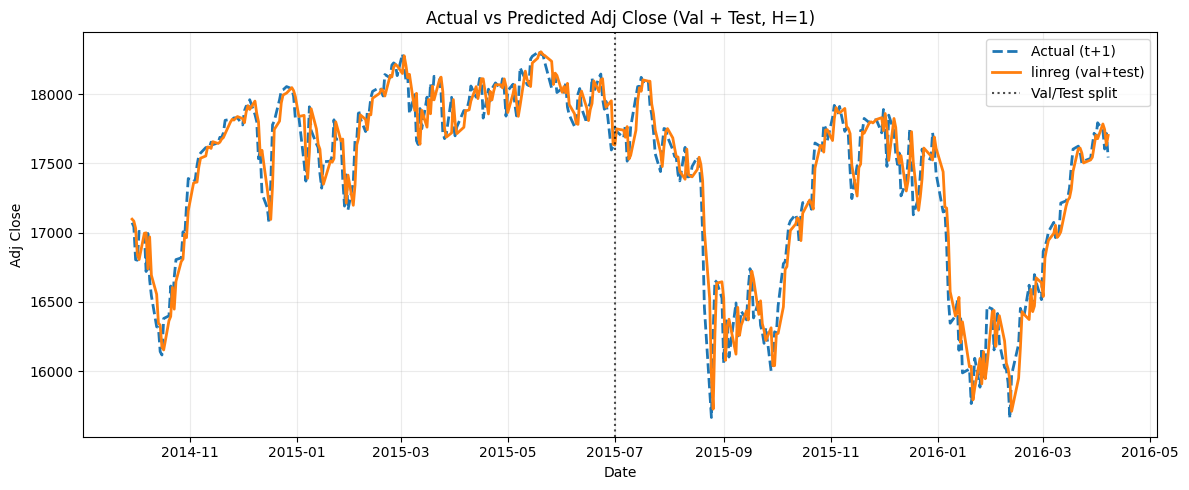

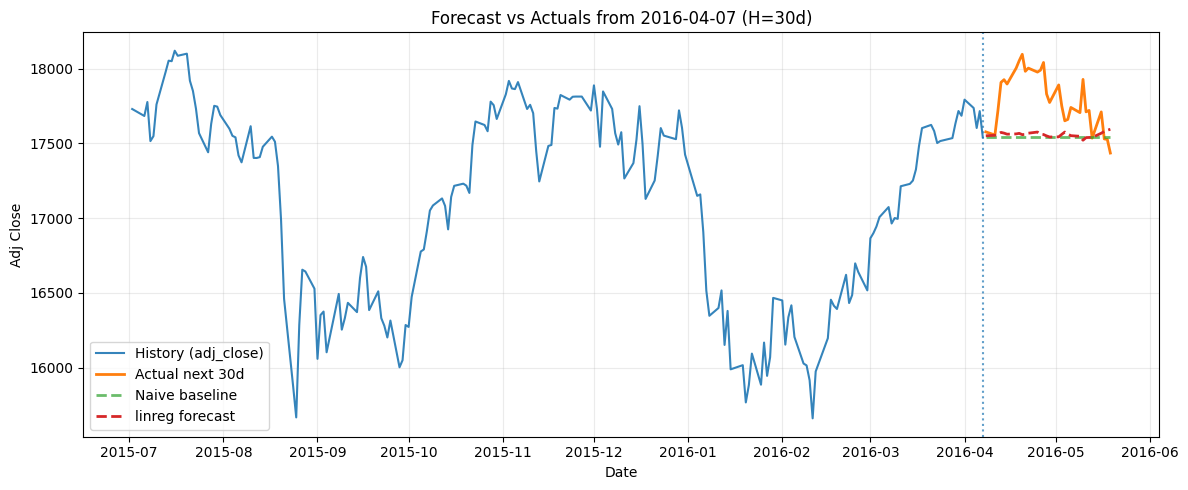

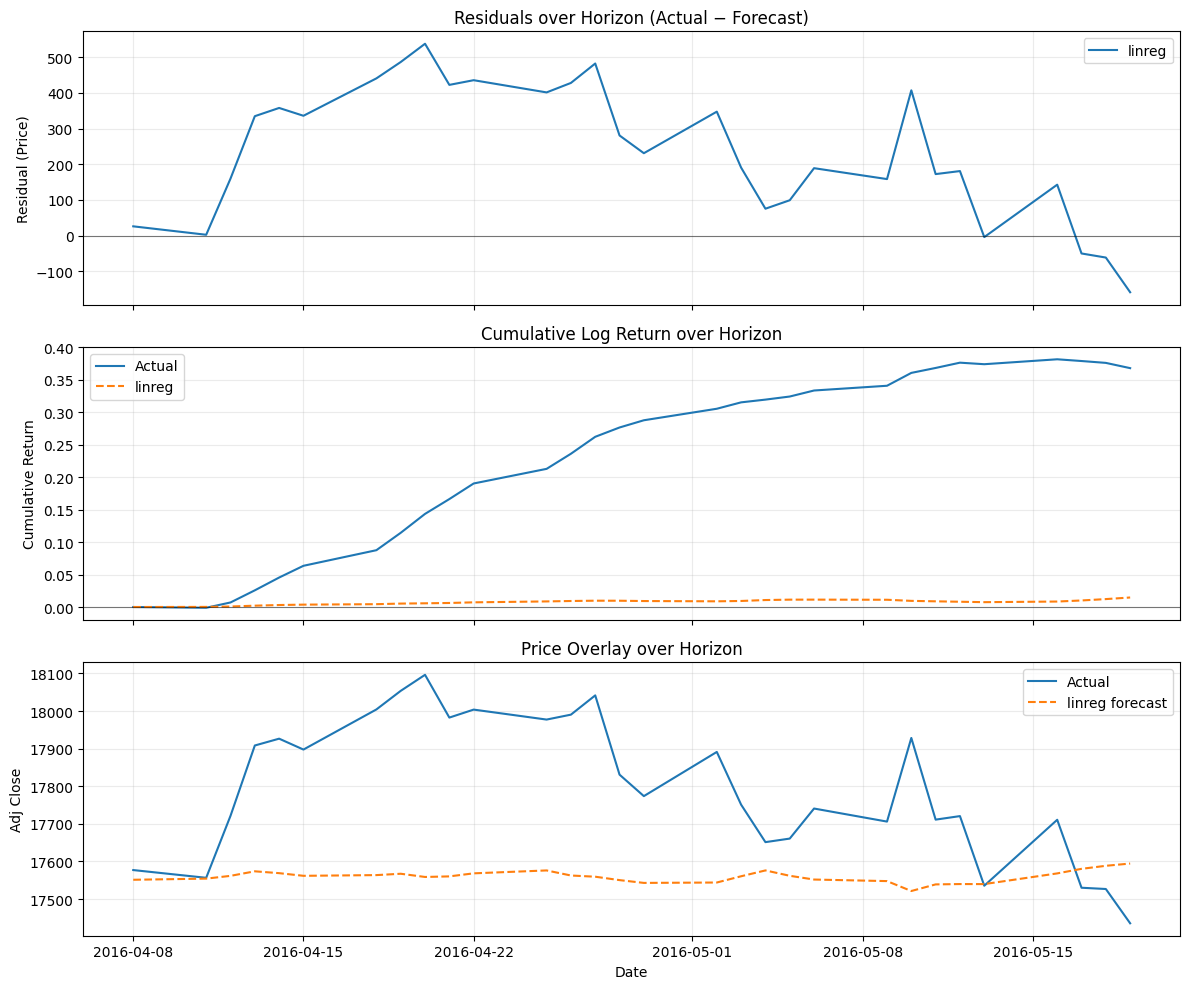

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
pd.DataFrame(results[0]["best_params"], index=[0])

,alpha,l1_ratio,max_iter,selection,random_state
0,0.009962,0.992638,4000,cyclic,42


In [9]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,569.383282,538138.962435,733.579554,1.69982,-0.013267


In [14]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

In [11]:
X_forecast = pd.read_parquet(Path(cfg.data.processed_dir) / f"{MODEL_NAME}_X_forecast.parquet")
p0 = float(pd.to_numeric(test["adj_close"], errors="coerce").iloc[-1])
past_prices = test["adj_close"].to_numpy()
linreg_recursive = recursive_forecast(results[0]["trainer"], X_forecast.iloc[[0]], HORIZON, p0=p0, past_prices=past_prices)

In [12]:
res_recursive = {
    "kind": "linreg_recursive",
    "horizon": HORIZON,
    "y_pred_val": None,
    "y_pred_test": None,
    "y_pred_last": linreg_recursive,
}
results_to_plot = [results[0], res_recursive]

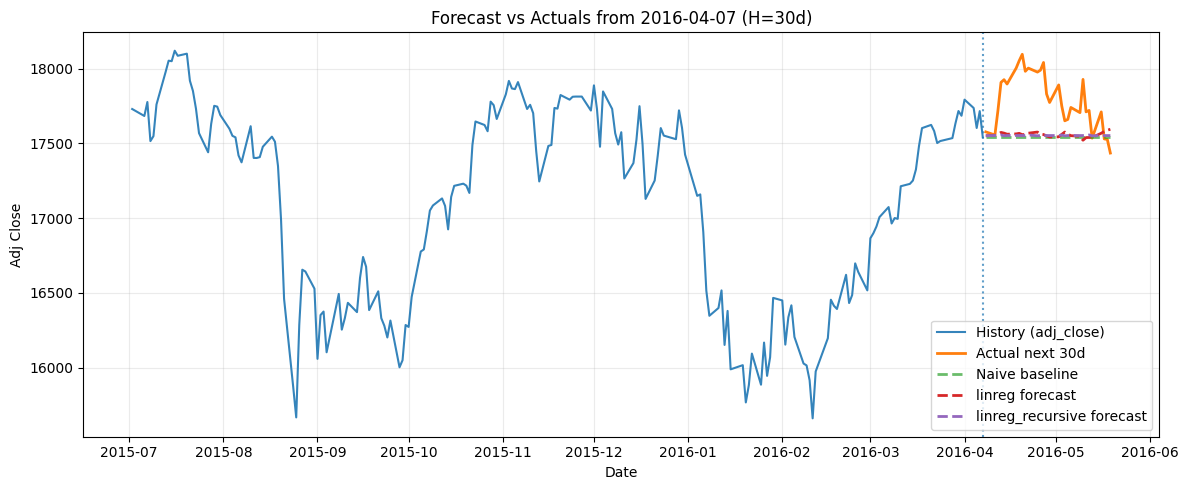

In [13]:
plot_forecast_overlay(test, forecast, results_to_plot, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_direct_vs_recursive.png")